In [2]:
pip install mlflow

  Using cached flask_cors-6.0.2-py3-none-any.whl.metadata (5.3 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached gunicorn-25.1.0-py3-none-any.whl.metadata (5.5 kB)
  Using cached huey-2.6.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached skops-0.13.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached databricks_sdk-0.96.0-py3-none-any.whl.metadata (40 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached sqlparse-0.5.5-py3-none-any.whl.metadata (4.7 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached werkzeug-3.1.6-py3-none-any.whl.metadata (4.0 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached pyasn1_

# RandomForest


Loading dataset...
Train size: 1360000
Test size: 240000

Reduced dataset:
Train size: 1360000
Test size: 240000


Running RF experiments:   0%|          | 0/1 [00:00<?, ?it/s]


Training RF_100trees_depth25


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   23.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   54.4s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    1.2s finished
2026/03/09 05:05:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 05:05:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Running RF experiments: 100%|██████████| 1/1 [01:48<00:00, 108.94s/


Ejecución Exitosa
F1 Score: 0.7427110151203721
Runtime: 103.33622646331787

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.71      0.73    120129
           1       0.73      0.78      0.75    119871

    accuracy                           0.74    240000
   macro avg       0.74      0.74      0.74    240000
weighted avg       0.74      0.74      0.74    240000

🏃 View run RF_100trees_depth25 at: http://ec2-54-167-162-85.compute-1.amazonaws.com:5000/#/experiments/8/runs/367a6a6f18dd48e6a6a21470dd364669
🧪 View experiment at: http://ec2-54-167-162-85.compute-1.amazonaws.com:5000/#/experiments/8

Todos los experimentos terminaron correctamente

Resultados finales:
  vectorizer ngram         model  n_estimators  max_depth  min_samples_split  \
0      TFIDF   1,2  RandomForest           100         25                  3   

         preprocessing  f1_score  
0  NoPunct + ElongNorm  0.742711  


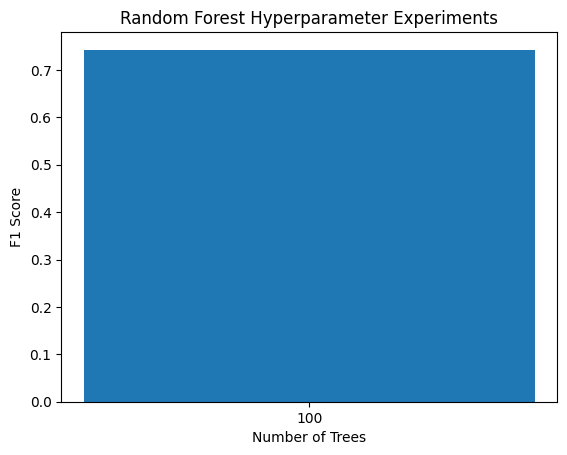

In [11]:
import numpy as np
import pandas as pd
import mlflow
import os
import time
import json
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier


# ===============================
# CONFIGURACIÓN MLFLOW
# ===============================

mlflow.set_tracking_uri("http://ec2-54-167-162-85.compute-1.amazonaws.com:5000")

experiment_name = "Parcial_NLP"
mlflow.set_experiment(experiment_name)


# ===============================
# OUTPUT FOLDERS
# ===============================

os.makedirs("outputs/model", exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)


# ===============================
# CARGAR DATASET FINAL
# ===============================

print("\nLoading dataset...")

train_df = pd.read_csv("./train_final.csv")
test_df = pd.read_csv("./test_final.csv")

print("Train size:", len(train_df))
print("Test size:", len(test_df))


# ===============================
# REDUCIR DATASET (debug rápido)
# ===============================

print("\nReduced dataset:")
print("Train size:", len(train_df))
print("Test size:", len(test_df))


# ===============================
# FEATURES
# ===============================

X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]


# ===============================
# HIPERPARÁMETROS A PROBAR
# ===============================

experiments = [

    {
        "n_estimators": 100,
        "max_depth": 25,
        "min_samples_split": 3
    }
]


ablation_results = []


# ===============================
# LOOP DE EXPERIMENTOS
# ===============================

for exp in tqdm(experiments, desc="Running RF experiments"):

    n_estimators_value = exp["n_estimators"]
    max_depth_value = exp["max_depth"]
    min_samples_split_value = exp["min_samples_split"]

    run_name = f"RF_{n_estimators_value}trees_depth{max_depth_value}"


    # ===============================
    # PIPELINE
    # ===============================

    pipeline = Pipeline([
        ("vectorizer", TfidfVectorizer(
            ngram_range=(1,2),
            max_features=200000
        )),
        ("model", RandomForestClassifier(
            n_estimators=n_estimators_value,
            max_depth=max_depth_value,
            min_samples_split=min_samples_split_value,
            n_jobs=-1,
            random_state=42,
            verbose=1
        ))
    ])


    print(f"\nTraining {run_name}")


    # ===============================
    # MLFLOW RUN
    # ===============================

    with mlflow.start_run(run_name=run_name):

        start_time = time.time()

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        end_time = time.time()

        runtime = end_time - start_time

        f1 = f1_score(y_test, y_pred, average="weighted")


        # ===============================
        # PARAMS
        # ===============================

        mlflow.log_params({
            "vectorizer": "TFIDF",
            "ngram_range": "1,2",
            "max_features": 200000,
            "model": "RandomForest",
            "n_estimators": n_estimators_value,
            "max_depth": max_depth_value,
            "min_samples_split": min_samples_split_value,
            "preprocessing": "NoPunct + ElongNorm",
            "dataset": "Sentiment140"
        })


        # ===============================
        # MÉTRICAS
        # ===============================

        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("runtime_seconds", runtime)


        # ===============================
        # TAGS
        # ===============================

        mlflow.set_tag("author", "Kevin")
        mlflow.set_tag("experiment_type", "ablation")
        mlflow.set_tag("feature_type", "TFIDF")
        mlflow.set_tag("dataset", "Sentiment140")


        # ===============================
        # LOG MODEL
        # ===============================

        mlflow.sklearn.log_model(pipeline, "model")


        # ===============================
        # MODEL CARD
        # ===============================

        model_card = {
            "model_name": run_name,
            "vectorizer": "TfidfVectorizer",
            "classifier": "RandomForestClassifier",
            "dataset": "Sentiment140",
            "preprocessing": "punctuation_removal + elongation_normalization",
            "n_estimators": n_estimators_value,
            "max_depth": max_depth_value,
            "min_samples_split": min_samples_split_value,
            "f1_score": float(f1),
            "author": "Kevin"
        }

        model_card_path = f"outputs/model/model_card_{run_name}.json"

        with open(model_card_path, "w") as f:
            json.dump(model_card, f, indent=4)


        # ===============================
        # GUARDAR RESULTADO ABLATION
        # ===============================

        ablation_results.append({
            "vectorizer": "TFIDF",
            "ngram": "1,2",
            "model": "RandomForest",
            "n_estimators": n_estimators_value,
            "max_depth": max_depth_value,
            "min_samples_split": min_samples_split_value,
            "preprocessing": "NoPunct + ElongNorm",
            "f1_score": f1
        })


        # ===============================
        # SUMMARY
        # ===============================

        summary = f"""
Experiment: {run_name}

Vectorizer: TFIDF Bigram
Model: RandomForestClassifier

Trees: {n_estimators_value}
Max Depth: {max_depth_value}

F1-score: {f1:.4f}

Dataset: Sentiment140
"""

        summary_path = f"outputs/reports/summary_{run_name}.txt"

        with open(summary_path, "w") as f:
            f.write(summary)


        # ===============================
        # LOG ARTIFACTS
        # ===============================

        mlflow.log_artifact(model_card_path)
        mlflow.log_artifact(summary_path)


        print("\nEjecución Exitosa")
        print("F1 Score:", f1)
        print("Runtime:", runtime)

        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred))


# ===============================
# TABLA FINAL ABLATION
# ===============================

ablation_df = pd.DataFrame(ablation_results)

ablation_df.to_csv("outputs/reports/ablation_results_rf.csv", index=False)


# ===============================
# ABLATION PLOT
# ===============================

plt.figure()

plt.bar(
    ablation_df["n_estimators"].astype(str),
    ablation_df["f1_score"]
)

plt.xlabel("Number of Trees")
plt.ylabel("F1 Score")
plt.title("Random Forest Hyperparameter Experiments")

plt.savefig("outputs/reports/ablation_plot_rf.png")


# ===============================
# WORK DISTRIBUTION
# ===============================

work_df = pd.DataFrame([{
    "member": "Kevin",
    "experiment": "RandomForest Hyperparameter Study"
}])

work_df.to_csv("outputs/reports/work_distribution_rf.csv", index=False)


print("\nTodos los experimentos terminaron correctamente")
print("\nResultados finales:")
print(ablation_df)

# LinearSVC

In [ ]:
import numpy as np
import pandas as pd
import mlflow
import os
import time
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
import re

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report
from sklearn.svm import LinearSVC

# ===============================
# CONFIGURACIÓN MLFLOW
# ===============================
mlflow.set_tracking_uri("http://ec2-54-174-164-37.compute-1.amazonaws.com:5000")
experiment_name = "Parcial_NLP"
mlflow.set_experiment(experiment_name)

# ===============================
# OUTPUT FOLDERS
# ===============================
os.makedirs("outputs/model", exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)

# ===============================
# CARGAR DATASET FINAL
# ===============================
print("\nLoading dataset...")
train_df = pd.read_csv("./train_final.csv")
test_df = pd.read_csv("./test_final.csv")
print("Train size:", len(train_df))
print("Test size:", len(test_df))

# ===============================
# TRANSFORMER DE PREPROCESAMIENTO
# ===============================
class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.punctuation_pattern = re.compile(r"[^\w\s]")
        self.elongation_pattern = re.compile(r"(.)\1{2,}")

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        cleaned = []
        for text in X:
            text = text.lower()
            text = re.sub(r"http\S+", "", text)
            text = re.sub(r"@\w+", "", text)
            text = re.sub(r"#\w+", "", text)
            text = self.punctuation_pattern.sub("", text)
            text = self.elongation_pattern.sub(r"\1\1", text)
            cleaned.append(text)
        return cleaned

# ===============================
# FEATURES
# ===============================
X_train = train_df["text"]
y_train = train_df["label"]
X_test = test_df["text"]
y_test = test_df["label"]

# ===============================
# HIPERPARÁMETROS A PROBAR
# ===============================
experiments = [
    {"C": 0.1, "max_iter": 500},
    {"C": 1.0, "max_iter": 1000},
    {"C": 10.0, "max_iter": 1000}
]

ablation_results = []

# ===============================
# LOOP DE EXPERIMENTOS
# ===============================
for exp in tqdm(experiments, desc="Running SVM experiments"):

    C_value = exp["C"]
    max_iter_value = exp["max_iter"]
    run_name = f"SVM_C{C_value}_iter{max_iter_value}"

    # ===============================
    # PIPELINE COMPLETO
    # ===============================
    pipeline = Pipeline([
        ("preprocessor", TextPreprocessor()),
        ("vectorizer", TfidfVectorizer(
            ngram_range=(1,2),
            max_features=200000
        )),
        ("model", LinearSVC(
            C=C_value,
            max_iter=max_iter_value,
            random_state=42
        ))
    ])

    print(f"\nTraining {run_name}")

    # ===============================
    # MLFLOW RUN
    # ===============================
    with mlflow.start_run(run_name=run_name):

        start_time = time.time()
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        end_time = time.time()

        runtime = end_time - start_time
        f1 = f1_score(y_test, y_pred, average="weighted")

        # PARAMS
        mlflow.log_params({
            "vectorizer": "TFIDF",
            "ngram_range": "1,2",
            "max_features": 200000,
            "model": "LinearSVC",
            "C": C_value,
            "max_iter": max_iter_value,
            "preprocessing": "punctuation_removal + elongation_normalization",
            "dataset": "Sentiment140"
        })

        # MÉTRICAS
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("runtime_seconds", runtime)

        # TAGS
        mlflow.set_tag("author", "Kevin")
        mlflow.set_tag("experiment_type", "ablation")
        mlflow.set_tag("feature_type", "TFIDF")
        mlflow.set_tag("dataset", "Sentiment140")

        # ===============================
        # LOG MODEL (INCLUYE PIPELINE COMPLETO)
        # ===============================
        mlflow.sklearn.log_model(pipeline, "model")

        # ===============================
        # MODEL CARD
        # ===============================
        model_card = {
            "model_name": run_name,
            "vectorizer": "TfidfVectorizer",
            "classifier": "LinearSVC",
            "dataset": "Sentiment140",
            "preprocessing": "punctuation_removal + elongation_normalization",
            "C": C_value,
            "max_iter": max_iter_value,
            "f1_score": float(f1),
            "author": "Kevin"
        }

        model_card_path = f"outputs/model/model_card_{run_name}.json"
        with open(model_card_path, "w") as f:
            json.dump(model_card, f, indent=4)

        # ===============================
        # GUARDAR RESULTADO ABLATION
        # ===============================
        ablation_results.append({
            "vectorizer": "TFIDF",
            "ngram": "1,2",
            "model": "LinearSVC",
            "C": C_value,
            "max_iter": max_iter_value,
            "preprocessing": "NoPunct + ElongNorm",
            "f1_score": f1
        })

        # SUMMARY
        summary = f"""
Experiment: {run_name}

Vectorizer: TFIDF Bigram
Model: LinearSVC
C: {C_value}
Max Iter: {max_iter_value}

F1-score: {f1:.4f}

Dataset: Sentiment140
"""
        summary_path = f"outputs/reports/summary_{run_name}.txt"
        with open(summary_path, "w") as f:
            f.write(summary)

        # LOG ARTIFACTS
        mlflow.log_artifact(model_card_path)
        mlflow.log_artifact(summary_path)

        print("\nEjecución Exitosa")
        print("F1 Score:", f1)
        print("Runtime:", runtime)
        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred))

# ===============================
# TABLA FINAL ABLATION
# ===============================
ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv("outputs/reports/ablation_results_svm.csv", index=False)

# ===============================
# ABLATION PLOT
# ===============================
plt.figure()
plt.bar(
    [str(r["C"]) for r in ablation_results],
    ablation_df["f1_score"]
)
plt.xlabel("C Value")
plt.ylabel("F1 Score")
plt.title("LinearSVC Hyperparameter Experiments")
plt.savefig("outputs/reports/ablation_plot_svm.png")

# ===============================
# WORK DISTRIBUTION
# ===============================
work_df = pd.DataFrame([{
    "member": "Kevin",
    "experiment": "LinearSVC Hyperparameter Study"
}])
work_df.to_csv("outputs/reports/work_distribution_svm.csv", index=False)

# LOG ARTIFACTS FINALES
mlflow.log_artifact("outputs/reports/ablation_results_svm.csv")
mlflow.log_artifact("outputs/reports/ablation_plot_svm.png")
mlflow.log_artifact("outputs/reports/work_distribution_svm.csv")

print("\nTodos los experimentos terminaron correctamente")
print("\nResultados finales:")
print(ablation_df)


Loading dataset...
Train size: 1360000
Test size: 240000


Running SVM experiments:   0%|          | 0/3 [00:00<?, ?it/s]


Training SVM_C0.1_iter500


2026/03/09 07:53:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 07:53:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Running SVM experiments:  33%|███▎      | 1/3 [01:29<02:59, 89.75s/it]


Ejecución Exitosa
F1 Score: 0.8240127149412476
Runtime: 84.56278133392334

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.81      0.82    120129
           1       0.82      0.84      0.83    119871

    accuracy                           0.82    240000
   macro avg       0.82      0.82      0.82    240000
weighted avg       0.82      0.82      0.82    240000

🏃 View run SVM_C0.1_iter500 at: http://ec2-54-174-164-37.compute-1.amazonaws.com:5000/#/experiments/8/runs/f7c954af854a4020820512177ed952e0
🧪 View experiment at: http://ec2-54-174-164-37.compute-1.amazonaws.com:5000/#/experiments/8

Training SVM_C1.0_iter1000


2026/03/09 07:56:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 07:56:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Running SVM experiments:  67%|██████▋   | 2/3 [03:53<02:01, 121.28s/it]


Ejecución Exitosa
F1 Score: 0.8152434235813945
Runtime: 138.20848751068115

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.80      0.81    120129
           1       0.81      0.83      0.82    119871

    accuracy                           0.82    240000
   macro avg       0.82      0.82      0.82    240000
weighted avg       0.82      0.82      0.82    240000

🏃 View run SVM_C1.0_iter1000 at: http://ec2-54-174-164-37.compute-1.amazonaws.com:5000/#/experiments/8/runs/2de8f360eed44fbfa4039db0f9c4b50a
🧪 View experiment at: http://ec2-54-174-164-37.compute-1.amazonaws.com:5000/#/experiments/8

Training SVM_C10.0_iter1000


# LogisticRegression

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


Train size: 1360000
Test size: 240000


Running Logistic Regression experiments:   0%|          | 0/3 [00:00<?, ?it/s]


Training LogReg_C0.1_liblinear


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
2026/03/09 07:31:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 07:31:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Running Logistic Regression experiments:  33%|███▎      | 1/3 [01:20<02

...

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
2026/03/09 07:32:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 07:32:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Running Logistic Regression experiments:  67%|██████▋   | 2/3 [02:32<01


Ejecución Exitosa
F1 Score: 0.8232077937024735
Runtime: 66.33755993843079

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.81      0.82    120129
           1       0.82      0.83      0.83    119871

    accuracy                           0.82    240000
   macro avg       0.82      0.82      0.82    240000
weighted avg       0.82      0.82      0.82    240000

🏃 View run LogReg_C1.0_lbfgs at: http://ec2-54-174-164-37.compute-1.amazonaws.com:5000/#/experiments/8/runs/fee89feecb724218b1589a0de8a886a6
🧪 View experiment at: http://ec2-54-174-164-37.compute-1.amazonaws.com:5000/#/experiments/8

Training LogReg_C10_lbfgs


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
2026/03/09 07:34:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 07:34:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Running Logistic Regression experiments: 100%|██████████| 3/3 [04:20<00


Ejecución Exitosa
F1 Score: 0.8184776125069184
Runtime: 103.42123746871948

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.81      0.82    120129
           1       0.81      0.83      0.82    119871

    accuracy                           0.82    240000
   macro avg       0.82      0.82      0.82    240000
weighted avg       0.82      0.82      0.82    240000

🏃 View run LogReg_C10_lbfgs at: http://ec2-54-174-164-37.compute-1.amazonaws.com:5000/#/experiments/8/runs/5857286e55864c72a253b5a257cb5be9
🧪 View experiment at: http://ec2-54-174-164-37.compute-1.amazonaws.com:5000/#/experiments/8



Todos los experimentos terminaron correctamente

Resultados finales:
  vectorizer ngram               model     C     solver penalty  \
0      TFIDF   1,2  LogisticRegression   0.1  liblinear      l2   
1      TFIDF   1,2  LogisticRegression   1.0      lbfgs      l2   
2      TFIDF   1,2  LogisticRegression  10.0      lbfgs      l2   

                                       preprocessing  f1_score  
0  lowercase + remove URLs + mentions + hashtags ...  0.810158  
1  lowercase + remove URLs + mentions + hashtags ...  0.823208  
2  lowercase + remove URLs + mentions + hashtags ...  0.818478  


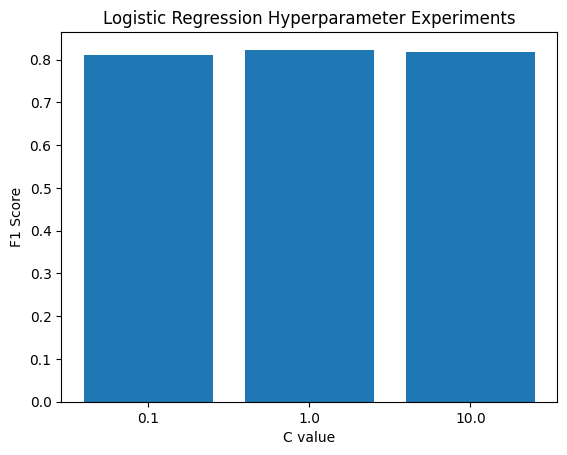

In [3]:
import numpy as np
import pandas as pd
import mlflow
import os
import time
import json
import matplotlib.pyplot as plt
import re

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm


# ===============================
# CONFIGURACIÓN MLFLOW
# ===============================
mlflow.set_tracking_uri("http://ec2-54-174-164-37.compute-1.amazonaws.com:5000")
experiment_name = "Parcial_NLP"
mlflow.set_experiment(experiment_name)

# ===============================
# OUTPUT FOLDERS
# ===============================
os.makedirs("outputs/model", exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)

# ===============================
# CARGAR DATASET FINAL
# ===============================
train_df = pd.read_csv("./train_final.csv")
test_df = pd.read_csv("./test_final.csv")

print("Train size:", len(train_df))
print("Test size:", len(test_df))

X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

# ===============================
# PREPROCESAMIENTO COMPLETO
# ===============================

# Función de limpieza
punctuation_pattern = re.compile(r"[^\w\s]")
elongation_pattern = re.compile(r"(.)\1{2,}")

def full_preprocessing(texts):
    processed = []
    for text in texts:
        text = text.lower()                            # pasar a minúsculas
        text = re.sub(r"http\S+", "", text)           # eliminar URLs
        text = re.sub(r"@\w+", "", text)              # eliminar menciones
        text = re.sub(r"#\w+", "", text)              # eliminar hashtags
        text = punctuation_pattern.sub("", text)      # eliminar puntuación/símbolos
        text = elongation_pattern.sub(r"\1\1", text)  # normalizar elongaciones
        processed.append(text)
    return processed

preprocessor = FunctionTransformer(full_preprocessing)

# ===============================
# HIPERPARÁMETROS A PROBAR
# ===============================
experiments = [
    {"C": 0.1, "solver": "liblinear", "penalty": "l2"},
    {"C": 1.0, "solver": "lbfgs", "penalty": "l2"},
    {"C": 10, "solver": "lbfgs", "penalty": "l2"}
]

ablation_results = []

# ===============================
# LOOP DE EXPERIMENTOS
# ===============================
for exp in tqdm(experiments, desc="Running Logistic Regression experiments"):
    
    C_value = exp["C"]
    solver_value = exp["solver"]
    penalty_value = exp["penalty"]

    run_name = f"LogReg_C{C_value}_{solver_value}"

    # ===============================
    # PIPELINE COMPLETO
    # ===============================
    pipeline = Pipeline([
        ("preprocessor", preprocessor),  # limpieza y normalización
        ("vectorizer", TfidfVectorizer(ngram_range=(1,2), max_features=200000)),
        ("model", LogisticRegression(
            C=C_value,
            solver=solver_value,
            penalty=penalty_value,
            max_iter=1000
        ))
    ])

    print(f"\nTraining {run_name}")

    # ===============================
    # MLFLOW RUN
    # ===============================
    with mlflow.start_run(run_name=run_name):

        start_time = time.time()
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        end_time = time.time()

        runtime = end_time - start_time
        f1 = f1_score(y_test, y_pred, average="weighted")

        # ===============================
        # PARAMS
        # ===============================
        mlflow.log_params({
            "vectorizer": "TFIDF",
            "ngram_range": "1,2",
            "max_features": 200000,
            "model": "LogisticRegression",
            "C": C_value,
            "solver": solver_value,
            "penalty": penalty_value,
            "max_iter": 1000,
            "preprocessing": "lowercase + remove URLs + mentions + hashtags + punctuation + normalize elongations",
            "dataset": "Sentiment140",
            "cv_folds": 5
        })

        # ===============================
        # MÉTRICAS
        # ===============================
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("runtime_seconds", runtime)

        # ===============================
        # TAGS
        # ===============================
        mlflow.set_tag("author", "Kevin")
        mlflow.set_tag("experiment_type", "ablation")
        mlflow.set_tag("feature_type", "TFIDF")
        mlflow.set_tag("dataset", "Sentiment140")

        # ===============================
        # LOG MODEL
        # ===============================
        mlflow.sklearn.log_model(pipeline, "model")

        # ===============================
        # MODEL CARD
        # ===============================
        model_card = {
            "model_name": run_name,
            "vectorizer": "TfidfVectorizer",
            "classifier": "LogisticRegression",
            "dataset": "Sentiment140",
            "preprocessing": "lowercase + remove URLs + mentions + hashtags + punctuation + normalize elongations",
            "C": C_value,
            "solver": solver_value,
            "penalty": penalty_value,
            "f1_score": float(f1),
            "author": "Kevin"
        }
        model_card_path = f"outputs/model/model_card_{run_name}.json"
        with open(model_card_path, "w") as f:
            json.dump(model_card, f, indent=4)

        # ===============================
        # GUARDAR RESULTADO ABLATION
        # ===============================
        ablation_results.append({
            "vectorizer": "TFIDF",
            "ngram": "1,2",
            "model": "LogisticRegression",
            "C": C_value,
            "solver": solver_value,
            "penalty": penalty_value,
            "preprocessing": "lowercase + remove URLs + mentions + hashtags + punctuation + normalize elongations",
            "f1_score": f1
        })

        # ===============================
        # SUMMARY
        # ===============================
        summary = f"""
Experiment: {run_name}

Vectorizer: TFIDF Bigram
Model: LogisticRegression
C: {C_value}
Solver: {solver_value}

F1-score: {f1:.4f}

Dataset: Sentiment140
"""
        summary_path = f"outputs/reports/summary_{run_name}.txt"
        with open(summary_path, "w") as f:
            f.write(summary)

        # ===============================
        # LOG ARTIFACTS
        # ===============================
        mlflow.log_artifact(model_card_path)
        mlflow.log_artifact(summary_path)

        print("\nEjecución Exitosa")
        print("F1 Score:", f1)
        print("Runtime:", runtime)
        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred))

# ===============================
# TABLA FINAL ABLATION
# ===============================
ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv("outputs/reports/ablation_results.csv", index=False)

# ===============================
# ABLATION PLOT
# ===============================
plt.figure()
plt.bar(ablation_df["C"].astype(str), ablation_df["f1_score"])
plt.xlabel("C value")
plt.ylabel("F1 Score")
plt.title("Logistic Regression Hyperparameter Experiments")
plt.savefig("outputs/reports/ablation_plot.png")

# ===============================
# WORK DISTRIBUTION
# ===============================
work_df = pd.DataFrame([{
    "member": "Kevin",
    "experiment": "LogisticRegression Hyperparameter Study"
}])
work_df.to_csv("outputs/reports/work_distribution.csv", index=False)

# ===============================
# LOG ARTIFACTS FINALES
# ===============================
mlflow.log_artifact("outputs/reports/ablation_results.csv")
mlflow.log_artifact("outputs/reports/ablation_plot.png")
mlflow.log_artifact("outputs/reports/work_distribution.csv")

print("\nTodos los experimentos terminaron correctamente")
print("\nResultados finales:")
print(ablation_df)